In [1]:
import numpy as np
import pandas as pd

In [2]:
valuations=pd.read_csv('player_valuations.csv')
players=pd.read_csv('players.csv')

In [3]:
merged_df=pd.merge(valuations, players, how='inner', left_on='player_id', right_on='player_id')

In [4]:
merged_df.sample(5)
merged_df.columns

Index(['player_id', 'date', 'market_value_in_eur_x', 'current_club_name_x',
       'current_club_id_x', 'player_club_domestic_competition_id',
       'first_name', 'last_name', 'name', 'last_season', 'current_club_id_y',
       'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'international_caps', 'international_goals',
       'current_national_team_id', 'url',
       'current_club_domestic_competition_id', 'current_club_name_y',
       'market_value_in_eur_y', 'highest_market_value_in_eur'],
      dtype='object')

In [5]:
# 1. Sort by date so the most recent valuations are at the top
merged_df['date'] = pd.to_datetime(merged_df['date'])
latest_valuations = merged_df.sort_values('date', ascending=False).drop_duplicates(subset=['player_id'])

# 2. Filter for players currently active in the Big 5 leagues
leagues_id = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']
final_df = latest_valuations[
    (latest_valuations['current_club_domestic_competition_id'].isin(leagues_id)) &
    (latest_valuations['last_season'] == 2025)
]

final_df.sample(5)
final_df.shape

(3012, 31)

In [6]:
final_df.columns

Index(['player_id', 'date', 'market_value_in_eur_x', 'current_club_name_x',
       'current_club_id_x', 'player_club_domestic_competition_id',
       'first_name', 'last_name', 'name', 'last_season', 'current_club_id_y',
       'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'international_caps', 'international_goals',
       'current_national_team_id', 'url',
       'current_club_domestic_competition_id', 'current_club_name_y',
       'market_value_in_eur_y', 'highest_market_value_in_eur'],
      dtype='object')

In [7]:
df=final_df[['name','player_id','market_value_in_eur_x','date_of_birth','position','current_club_name_x','current_club_domestic_competition_id','sub_position','height_in_cm','country_of_citizenship','contract_expiration_date','highest_market_value_in_eur','foot']]

In [8]:
df.sample(5)

,name,player_id,market_value_in_eur_x,date_of_birth,position,current_club_name_x,current_club_domestic_competition_id,sub_position,height_in_cm,country_of_citizenship,contract_expiration_date,highest_market_value_in_eur,foot
648058,Rolando Mandragora,308279,9000000,1997-06-29 00:00:00,Midfield,ACF Fiorentina,IT1,Defensive Midfield,183.0,Italy,2028-06-30 00:00:00,15000000.0,left
623995,Triston Rowe,984593,500000,2006-10-02 00:00:00,Defender,FC Annecy,GB1,Right-Back,183.0,England,NaN,500000.0,right
651701,Enzo Le Fée,633992,28000000,2000-02-03 00:00:00,Midfield,Sunderland AFC,GB1,Central Midfield,173.0,France,2029-06-30 00:00:00,28000000.0,right
645641,Malik Tillman,467437,30000000,2002-05-28 00:00:00,Midfield,Bayer 04 Leverkusen,L1,Attacking Midfield,187.0,United States,2030-06-30 00:00:00,35000000.0,right
651319,Hjalmar Ekdal,392179,5000000,1998-10-21 00:00:00,Defender,Burnley FC,GB1,Centre-Back,187.0,Sweden,2027-06-30 00:00:00,8000000.0,right


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3012 entries, 656253 to 458646
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   name                                  3012 non-null   object 
 1   player_id                             3012 non-null   int64  
 2   market_value_in_eur_x                 3012 non-null   int64  
 3   date_of_birth                         3012 non-null   object 
 4   position                              3012 non-null   object 
 5   current_club_name_x                   3012 non-null   object 
 6   current_club_domestic_competition_id  3012 non-null   object 
 7   sub_position                          3012 non-null   object 
 8   height_in_cm                          2985 non-null   float64
 9   country_of_citizenship                3012 non-null   object 
 10  contract_expiration_date              2666 non-null   object 
 11  highest_market_

In [10]:
df.isnull().sum()

name                                      0
player_id                                 0
market_value_in_eur_x                     0
date_of_birth                             0
position                                  0
current_club_name_x                       0
current_club_domestic_competition_id      0
sub_position                              0
height_in_cm                             27
country_of_citizenship                    0
contract_expiration_date                346
highest_market_value_in_eur               0
foot                                     29
dtype: int64

In [11]:
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].mean())
df['contract_expiration_date'] = df['contract_expiration_date'].fillna(df['contract_expiration_date'].mode()[0])
df['foot'] = df['foot'].fillna(df['foot'].mode()[0])

/tmp/ipykernel_32795/3620052141.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].mean())
/tmp/ipykernel_32795/3620052141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['contract_expiration_date'] = df['contract_expiration_date'].fillna(df['contract_expiration_date'].mode()[0])
/tmp/ipykernel_32795/3620052141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [12]:
df.sample(5)


,name,player_id,market_value_in_eur_x,date_of_birth,position,current_club_name_x,current_club_domestic_competition_id,sub_position,height_in_cm,country_of_citizenship,contract_expiration_date,highest_market_value_in_eur,foot
649041,Matthis Abline,659543,20000000,2003-03-28 00:00:00,Attack,FC Nantes,FR1,Centre-Forward,182.0,France,2028-06-30 00:00:00,22000000.0,right
645554,Yannik Keitel,342039,2000000,2000-02-15 00:00:00,Midfield,FC Augsburg,L1,Defensive Midfield,186.0,Germany,2027-06-30 00:00:00,5000000.0,both
651585,Cheick Doucouré,543387,10000000,2000-01-08 00:00:00,Midfield,Crystal Palace,GB1,Defensive Midfield,180.0,Mali,2029-06-30 00:00:00,35000000.0,right
651525,Giorgi Mamardashvili,502676,28000000,2000-09-29 00:00:00,Goalkeeper,Liverpool FC,GB1,Goalkeeper,197.0,Georgia,2031-06-30 00:00:00,45000000.0,left
645597,Stefan Schimmer,394033,300000,1994-04-28 00:00:00,Attack,1.FC Heidenheim 1846,L1,Centre-Forward,185.0,Germany,2027-06-30 00:00:00,500000.0,right


In [13]:
df.dtypes

name                                     object
player_id                                 int64
market_value_in_eur_x                     int64
date_of_birth                            object
position                                 object
current_club_name_x                      object
current_club_domestic_competition_id     object
sub_position                             object
height_in_cm                            float64
country_of_citizenship                   object
contract_expiration_date                 object
highest_market_value_in_eur             float64
foot                                     object
dtype: object

In [14]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365
df.drop(columns=['date_of_birth'], inplace=True)

/tmp/ipykernel_32795/378081217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
/tmp/ipykernel_32795/378081217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365
/tmp/ipykernel_32795/378081217.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [15]:
df.sample(5)

,name,player_id,market_value_in_eur_x,position,current_club_name_x,current_club_domestic_competition_id,sub_position,height_in_cm,country_of_citizenship,contract_expiration_date,highest_market_value_in_eur,foot,age
645505,Chris Führich,272278,12000000,Attack,VfB Stuttgart,L1,Left Winger,181.0,Germany,2028-06-30 00:00:00,28000000.0,right,28
647431,Yu Hirakawa,936237,1000000,Attack,Hull City,GB1,Right Winger,172.0,Japan,2026-06-30 00:00:00,1000000.0,right,25
648371,Vitinha,586853,8000000,Attack,Genoa CFC,IT1,Centre-Forward,178.0,Portugal,2028-06-30 00:00:00,22000000.0,right,26
645491,Jonas Omlin,247915,800000,Goalkeeper,Bayer 04 Leverkusen,L1,Goalkeeper,190.0,Switzerland,2029-06-30 00:00:00,9000000.0,right,32
649103,Warren Kamanzi,794758,1200000,Defender,FC Toulouse,FR1,Right-Back,177.0,Norway,2028-06-30 00:00:00,2000000.0,right,25


In [16]:
df.dtypes

name                                     object
player_id                                 int64
market_value_in_eur_x                     int64
position                                 object
current_club_name_x                      object
current_club_domestic_competition_id     object
sub_position                             object
height_in_cm                            float64
country_of_citizenship                   object
contract_expiration_date                 object
highest_market_value_in_eur             float64
foot                                     object
age                                       int64
dtype: object

In [17]:
# 1. Convert text groupings to Category dtypes
categorical_cols = [
    'position', 'sub_position', 'foot', 'country_of_citizenship', 
    'current_club_name_x', 'current_club_domestic_competition_id'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# 2. Convert text dates to true Datetime objects
df['contract_expiration_date'] = pd.to_datetime(df['contract_expiration_date'])

# 3. Engineer a numeric feature for the ML model (Days left on contract)
# Assuming today is roughly September 2026 based on your current season data
today = pd.to_datetime('2026-09-16')
df['contract_days_left'] = (df['contract_expiration_date'] - today).dt.days

# Drop the original date column since the model can't read it
df.drop(columns=['contract_expiration_date'], inplace=True)

# 4. Verify the new, optimized data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3012 entries, 656253 to 458646
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   name                                  3012 non-null   object  
 1   player_id                             3012 non-null   int64   
 2   market_value_in_eur_x                 3012 non-null   int64   
 3   position                              3012 non-null   category
 4   current_club_name_x                   3012 non-null   category
 5   current_club_domestic_competition_id  3012 non-null   category
 6   sub_position                          3012 non-null   category
 7   height_in_cm                          3012 non-null   float64 
 8   country_of_citizenship                3012 non-null   category
 9   highest_market_value_in_eur           3012 non-null   float64 
 10  foot                                  3012 non-null   category
 11  ag

/tmp/ipykernel_32795/36690323.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical_cols] = df[categorical_cols].astype('category')
/tmp/ipykernel_32795/36690323.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['contract_expiration_date'] = pd.to_datetime(df['contract_expiration_date'])
/tmp/ipykernel_32795/36690323.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [18]:
df['name'] = df['name'].astype('string')

/tmp/ipykernel_32795/3177531412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['name'] = df['name'].astype('string')


In [19]:
df.sample(5)

,name,player_id,market_value_in_eur_x,position,current_club_name_x,current_club_domestic_competition_id,sub_position,height_in_cm,country_of_citizenship,highest_market_value_in_eur,foot,age,contract_days_left
648344,Adam Obert,568333,7000000,Defender,Cagliari Calcio,IT1,Left-Back,188.0,Slovakia,7000000.0,left,24,1383
654970,Largie Ramazani,518644,8000000,Attack,Valencia CF,GB1,Left Winger,168.0,Belgium,10000000.0,right,25,653
649221,Telli Siwe,1091353,1000000,Defender,AJ Auxerre,FR1,Centre-Back,185.0,France,1000000.0,right,21,1018
648582,Jeff Ekhator,934878,18000000,Attack,Genoa CFC,IT1,Centre-Forward,188.0,Italy,18000000.0,right,19,1748
655514,Ismael Bekhoucha,1164331,300000,Defender,Getafe CF,ES1,Right-Back,176.0,Morocco,300000.0,right,21,653


In [20]:
df['foot'].unique()

['right', 'left', 'both']
Categories (3, object): ['both', 'left', 'right']

In [21]:
from ydata_profiling import ProfileReport

# Generate the comprehensive profile report
# explorative=True adds more in-depth calculations for correlations and text analysis
profile = ProfileReport(df, title="Football Transfer Values: Profiling Report", explorative=True)

# This will render the interactive HTML report directly below the cell
profile.to_notebook_iframe()

# Optional: Save it as a standalone HTML file in your Football folder
# profile.to_file("transfer_values_report.html")

/tmp/ipykernel_32795/1293917844.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 392.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
import soccerdata as sd
import warnings

# Temporarily suppress the pandas FutureWarning about concatenation 
# (which you can see flooding your terminal in the image)
warnings.simplefilter(action='ignore', category=FutureWarning)

seasons = [2023, 2024, 2025]
fbref = sd.FBref(leagues="Big 5 European Leagues Combined", seasons=seasons)

fbref_data = {}
# Only using the 4 highly predictive tables supported by soccerdata
stat_types = ['standard', 'shooting', 'misc', 'keeper']

for stat in stat_types:
    print(f"Fetching {stat} stats...")
    df = fbref.read_player_season_stats(stat_type=stat)
    
    # Clean up the MultiIndex columns
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    fbref_data[stat] = df

print("All supported stats fetched successfully!")

[10/05/26 16:47:33] INFO     Saving cached data to /home/laksh18k/soccerdata/data/FBref              ]8;id=13177751;file:///home/laksh18k/Desktop/Projects/Football/Football/lib/python3.12/site-packages/soccerdata/_common.py\_common.py]8;;\:]8;id=13177752;file:///home/laksh18k/Desktop/Projects/Football/Football/lib/python3.12/site-packages/soccerdata/_common.py#250\250]8;;\

Fetching standard stats...
Fetching shooting stats...
Fetching misc stats...
Fetching keeper stats...
All supported stats fetched successfully!


In [26]:
from pathlib import Path

# Create a directory to store the scraped files
output_dir = Path("data/fbref_raw")
output_dir.mkdir(parents=True, exist_ok=True)

# Save each dataframe
for stat, data in fbref_data.items():
    # Save as CSV
    csv_path = output_dir / f"fbref_{stat}.csv"
    data.to_csv(csv_path)
    
    # Optional but recommended: Save as Parquet (faster & preserves types)
    # parquet_path = output_dir / f"fbref_{stat}.parquet"
    # data.to_parquet(parquet_path)
    
    print(f"Saved: {csv_path}")

print("All FBref datasets backed up successfully!")

Saved: data/fbref_raw/fbref_standard.csv
Saved: data/fbref_raw/fbref_shooting.csv
Saved: data/fbref_raw/fbref_misc.csv
Saved: data/fbref_raw/fbref_keeper.csv
All FBref datasets backed up successfully!


In [28]:
import pandas as pd
from pathlib import Path

output_dir = Path("data/fbref_raw")

# 1. Load the saved CSVs (or reference fbref_data directly if still in memory)
if 'fbref_data' in globals():
    fbref_standard = fbref_data['standard'].copy()
    fbref_shooting = fbref_data['shooting'].copy()
    fbref_misc = fbref_data['misc'].copy()
else:
    fbref_standard = pd.read_csv(output_dir / "fbref_standard.csv")
    fbref_shooting = pd.read_csv(output_dir / "fbref_shooting.csv")
    fbref_misc = pd.read_csv(output_dir / "fbref_misc.csv")

# 2. Reset index if league/season/team/player are still indices
for df_temp in [fbref_standard, fbref_shooting, fbref_misc]:
    if not isinstance(df_temp.index, pd.RangeIndex):
        df_temp.reset_index(inplace=True)

# Helper to identify the position column regardless of column flattening
def get_pos_col(df_to_check):
    for col in df_to_check.columns:
        if str(col).endswith('Pos') or col == 'Pos':
            return col
    return None

pos_col = get_pos_col(fbref_standard)

# 3. Filter out Goalkeepers across ALL seasons (2023, 2024, 2025)
if pos_col:
    fbref_outfield_std = fbref_standard[~fbref_standard[pos_col].astype(str).str.contains('GK', na=False)]
    fbref_outfield_sht = fbref_shooting[~fbref_shooting[pos_col].astype(str).str.contains('GK', na=False)]
    fbref_outfield_msc = fbref_misc[~fbref_misc[pos_col].astype(str).str.contains('GK', na=False)]
else:
    fbref_outfield_std = fbref_standard.copy()
    fbref_outfield_sht = fbref_shooting.copy()
    fbref_outfield_msc = fbref_misc.copy()

# 4. Identify common joining keys (handles lowercase or titlecase keys)
join_keys = [c for c in ['league', 'season', 'team', 'player'] if c in fbref_outfield_std.columns]

# 5. Merge the 3 tables horizontally across all seasons
fbref_outfield_combined = pd.merge(
    fbref_outfield_std,
    fbref_outfield_sht,
    on=join_keys,
    how='inner',
    suffixes=('', '_drop_sht')
)

fbref_outfield_combined = pd.merge(
    fbref_outfield_combined,
    fbref_outfield_msc,
    on=join_keys,
    how='inner',
    suffixes=('', '_drop_msc')
)

# 6. Drop redundant duplicate columns
fbref_outfield_combined = fbref_outfield_combined.loc[
    :, ~fbref_outfield_combined.columns.str.contains('_drop_')
]

print(f"Combined FBref outfield rows: {len(fbref_outfield_combined)}")

Combined FBref outfield rows: 8539


In [29]:
from thefuzz import process, fuzz

# Map season string formats if needed (e.g., '2324' or 2023)
# Transfermarkt seasons are stored as integer start-years: 2023, 2024, 2025
if fbref_outfield_combined['season'].dtype == object:
    # Convert '2324' -> 2023, '2425' -> 2024, '2526' -> 2025 if formatted as strings
    season_str_map = {'2223': 2022, '2324': 2023, '2425': 2024, '2526': 2025}
    fbref_outfield_combined['season'] = fbref_outfield_combined['season'].map(season_str_map).fillna(fbref_outfield_combined['season'])

fbref_outfield_combined['season'] = fbref_outfield_combined['season'].astype(int)

# Extract unique names
unique_tm_names = outfield_df['name'].unique()
fbref_names = fbref_outfield_combined['player'].unique().tolist()

# Build the fuzzy mapping dictionary
name_map = {}
for name in unique_tm_names:
    match = process.extractOne(name, fbref_names, scorer=fuzz.token_sort_ratio)
    if match and match[1] >= 80:
        name_map[name] = match[0]

outfield_df['matched_fbref_name'] = outfield_df['name'].map(name_map)

# Merge on both name AND season to align stats with valuations
final_model_data = pd.merge(
    outfield_df,
    fbref_outfield_combined,
    left_on=['matched_fbref_name', 'season'],
    right_on=['player', 'season'],
    how='inner'
)

print(f"Final dataset size: {len(final_model_data)} rows ready for ML")
final_model_data[['name', 'season', 'market_value_in_eur_x', 'current_club_name_x']].head()

Final dataset size: 6489 rows ready for ML


,name,season,market_value_in_eur_x,current_club_name_x
0,James Milner,2023,1000000,Brighton & Hove Albion
1,James Milner,2024,1000000,Brighton & Hove Albion
2,James Milner,2025,500000,Brighton & Hove Albion
3,Jonas Hofmann,2023,10000000,Bayer 04 Leverkusen
4,Jonas Hofmann,2024,2000000,Bayer 04 Leverkusen


In [31]:
final_model_data.sample(5)
final_model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6489 entries, 0 to 6488
Data columns (total 78 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   player_id                             6489 non-null   int64         
 1   season                                6489 non-null   int64         
 2   date                                  6489 non-null   datetime64[ns]
 3   market_value_in_eur_x                 6489 non-null   int64         
 4   current_club_name_x                   6489 non-null   object        
 5   current_club_id_x                     6489 non-null   int64         
 6   player_club_domestic_competition_id   6181 non-null   object        
 7   first_name                            6271 non-null   object        
 8   last_name                             6489 non-null   object        
 9   name                                  6489 non-null   object        
 10  

In [32]:
final_model_data.to_csv('data/final_model_data.csv', index=False)

In [33]:
# List metadata/identifier columns that have zero predictive value
drop_cols = [
    'player_id', 'matched_fbref_name', 'player', 'name', 
    'image_url', 'url', 'first_name', 'last_name', 'player_code'
]

# Keep only existing columns from the drop list
cleaned_df = final_model_data.drop(columns=[c for c in drop_cols if c in final_model_data.columns])

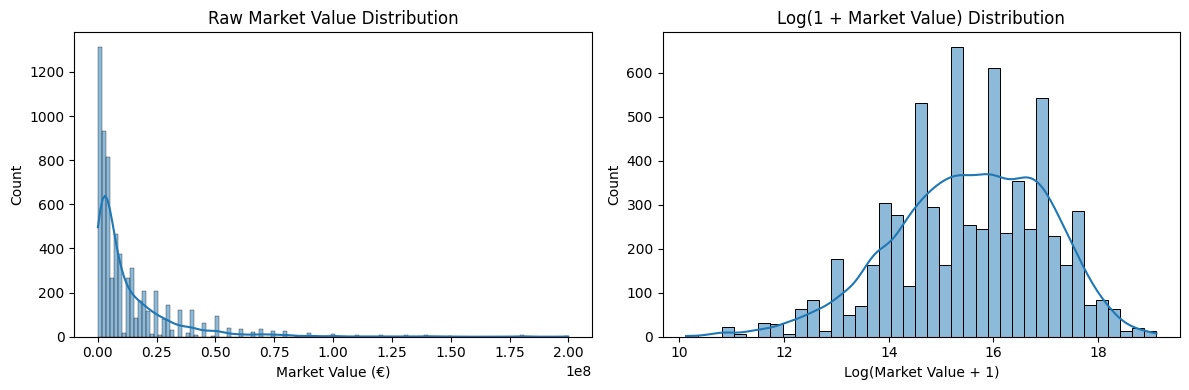

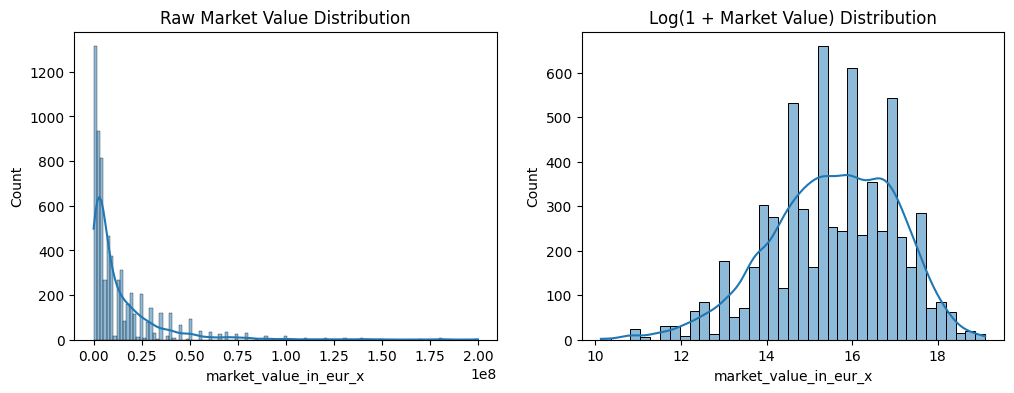

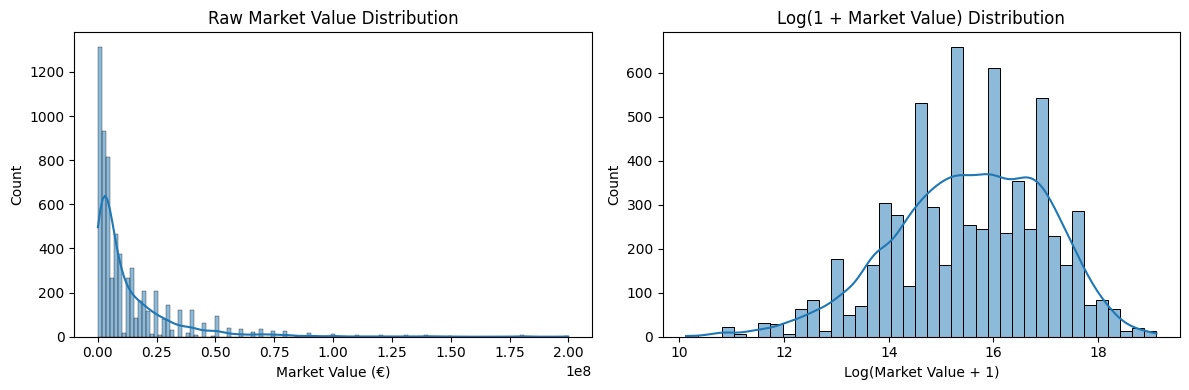

In [35]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Raw target distribution
sns.histplot(cleaned_df['market_value_in_eur_x'], kde=True, ax=ax[0])
ax[0].set_title("Raw Market Value Distribution")
ax[0].set_xlabel("Market Value (€)")

# Log-transformed target distribution
sns.histplot(np.log1p(cleaned_df['market_value_in_eur_x']), kde=True, ax=ax[1])
ax[1].set_title("Log(1 + Market Value) Distribution")
ax[1].set_xlabel("Log(Market Value + 1)")

plt.tight_layout()
fig

In [36]:
missing_pct = (cleaned_df.isnull().sum() / len(cleaned_df)) * 100
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Columns with missing values (%):")
print(missing_report.head(20))

Columns with missing values (%):
Performance_PKwon                      100.000000
Performance_PKcon                      100.000000
current_national_team_id                97.904145
agent_name                              24.441362
Standard_G/SoT                          21.374634
league                                  18.400370
international_caps                      14.516875
international_goals                     14.516875
contract_expiration_date                11.450146
Standard_SoT%                            9.955309
Standard_G/Sh                            9.955309
player_club_domestic_competition_id      4.746494
height_in_cm                             0.631838
country_of_birth                         0.539374
city_of_birth                            0.539374
foot                                     0.493142
nation_                                  0.046232
date_of_birth                            0.030821
born_                                    0.015411
age_             

In [37]:
import numpy as np

# 1. Drop columns with massive missing data or redundant text
cols_to_drop = [
    'Performance_PKwon', 'Performance_PKcon', 'current_national_team_id', 
    'agent_name', 'league', 'contract_expiration_date', 
    'player_club_domestic_competition_id', 'city_of_birth', 'nation_', 'born_', 'age_', 'dtype'
]
cleaned_df = cleaned_df.drop(columns=[c for c in cols_to_drop if c in cleaned_df.columns])

# 2. Fill math-error NaNs (Divide by zero for players with 0 shots)
shooting_ratios = ['Standard_G/SoT', 'Standard_SoT%', 'Standard_G/Sh']
cleaned_df[shooting_ratios] = cleaned_df[shooting_ratios].fillna(0)

# 3. Fill missing international experience with 0
intl_cols = ['international_caps', 'international_goals']
cleaned_df[intl_cols] = cleaned_df[intl_cols].fillna(0)

# 4. Impute the remaining numerical features with the median
cleaned_df['height_in_cm'] = cleaned_df['height_in_cm'].fillna(cleaned_df['height_in_cm'].median())

# 5. Impute categorical features with the mode
cleaned_df['foot'] = cleaned_df['foot'].fillna(cleaned_df['foot'].mode()[0])

# 6. Drop any tiny remaining stray NaNs (like the <1% missing country_of_birth)
cleaned_df = cleaned_df.dropna()

# 7. Extract X (Features) and y (Target)
# Apply log1p to the target based on the bell-curve shown in your EDA
y = np.log1p(cleaned_df['market_value_in_eur_x'])
X = cleaned_df.drop(columns=['market_value_in_eur_x'])

print(f"Final Features (X) Shape: {X.shape}")
print(f"Final Target (y) Shape: {y.shape}")

Final Features (X) Shape: (6452, 57)
Final Target (y) Shape: (6452,)


In [38]:
numeric_df = cleaned_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['market_value_in_eur_x'].sort_values(ascending=False)

print("Top 15 Most Positively Correlated Features:")
print(corr.head(15))

print("\nTop 10 Most Negatively Correlated Features:")
print(corr.tail(10))

Top 15 Most Positively Correlated Features:
market_value_in_eur_x          1.000000
market_value_in_eur_y          0.891061
highest_market_value_in_eur    0.828295
Performance_G+A                0.506812
Standard_Sh                    0.481231
Standard_SoT                   0.477910
Performance_G-PK               0.464843
Standard_Gls                   0.457308
Performance_Gls                0.457308
Performance_Ast                0.425754
Playing Time_Min               0.345132
90s_                           0.345084
Playing Time_90s               0.345084
Playing Time_Starts            0.343920
Performance_Fld                0.342081
Name: market_value_in_eur_x, dtype: float64

Top 10 Most Negatively Correlated Features:
Standard_Sh/90        0.108854
Per 90 Minutes_Ast    0.105373
Standard_SoT/90       0.083356
season                0.031213
Performance_CrdR      0.027866
Performance_2CrdY     0.016813
height_in_cm          0.004633
Performance_OG        0.000140
current_club_id_y  

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Split the data FIRST (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the categorical columns to encode
cat_cols = ['position', 'foot']

# 3. Build the ColumnTransformer
# drop='first' removes one category to prevent perfect collinearity (the dummy variable trap)
# handle_unknown='ignore' prevents crashes if the test set has a category not seen in training
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough' # Keep all other numerical columns exactly as they are
)

# 4. Fit the preprocessor on the training data ONLY, then transform both sets
# We wrap the output back into a pandas DataFrame to retain feature names for feature importance plots later
X_train_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out()
)

X_test_encoded = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out()
)

print(f"Training features shape: {X_train_encoded.shape}")
print(f"Testing features shape: {X_test_encoded.shape}")

Training features shape: (5161, 59)
Testing features shape: (1291, 59)


In [40]:
cleaned_df.to_csv('data/cleaned_model_data.csv', index=False)